# LDPC vs GRAND as Information Reconciliation for BB84 — Research Log

**Research question.** For BB84 sifted keys produced by our Qiskit-Aer simulator, where (in the
block-length × QBER plane) does GRAND (noise-guessing decoding) outperform a rate-adaptive LDPC
baseline as the information-reconciliation step — and is there a clear *crossover point*?

**Scope & honesty rules.**
- This is an *experimental comparison*, not a new decoding algorithm.
- A clear crossover is a useful finding; an ambiguous or negative result is reported as-is.
- The LDPC baseline is deliberately **rate-adaptive** (code rate chosen from the estimated QBER
  using pre-characterised code performance). A fixed-rate LDPC strawman would flatter GRAND.
- Any result that looks too clean gets flagged and sanity-checked before we build on it.

**Stages.** 1) Setup & calibration (this section) → 2) Spike experiment on a small grid →
3) Expand the grid *or* report the honest negative, depending on what the spike shows.

*Branch: `error-analysis-ldpc-vs-grand`. Supporting library: [`reconciliation.py`](reconciliation.py).*

## 1. Setup

**What the existing simulator provides** (`bb84_core.py`, `bb84_noise.py`, `bb84_runner.py`):
Alice/Bob/Eve parties, five Aer-backed noise models, sifting and QBER estimation with Wilson CIs.
The stock runner submits **one Aer job per qubit**, which is far too slow for the ~10⁵-bit key
pools we need, so `reconciliation.generate_sifted_pool` reuses the *same* `Alice`/`Bob` classes and
the *same* `QuantumChannel` noise model but batches all single-qubit circuits into a few large Aer
jobs (~100× faster, statistically identical channel).

**What this study adds** (`reconciliation.py`):
- A common **syndrome-based reconciliation protocol**: Alice publishes `s_A = H·x (mod 2)`
  (m bits leaked); Bob solves for the most likely error vector `e` with `H·e = s_A ⊕ H·y`.
  Both methods use this same protocol, so **leakage accounting is identical: leak = m**.
- **LDPC**: sparse regular parity-check matrices built with `pyldpc` (`d_v ≥ 3`; `d_v = 2`
  cycle codes were tried and fail BP badly), decoded with syndrome-target sum-product belief
  propagation. `pyldpc`'s own decoder targets AWGN codeword transmission, which is why the BP
  decoder here is custom — but code *construction* comes from `pyldpc`.
- **GRAND**: dense random parity-check matrix (the natural code family for GRAND — random linear
  codes are near-ML-optimal at short lengths), error patterns enumerated in increasing
  Hamming-weight order (exactly ML order for a BSC with p < ½), abandoning after a fixed guess
  budget.
- Note: the repo's existing `bb84_grand.py` validates candidates against **Alice's key itself**
  ("oracle" mode). That is fine for demonstrating the guessing mechanics but is not a runnable
  protocol — Bob doesn't have Alice's key. Here GRAND is put on the same syndrome footing as LDPC.

In [1]:
import sys, json, time, math, platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import qiskit, qiskit_aer

sys.path.insert(0, str(Path.cwd()))
import reconciliation as rc
from reconciliation import (generate_sifted_pool, LDPCReconciler, GRANDReconciler,
                            h2, result_row, _grand_search)

RESULTS = Path("results_error_analysis"); RESULTS.mkdir(exist_ok=True)
SEED_CAL, SEED_POOL, SEED_CODE = 11_000, 20_260_718, 0

print("python", platform.python_version(), "| qiskit", qiskit.__version__,
      "| qiskit-aer", qiskit_aer.__version__)
print("numpy", np.__version__, "| pandas", pd.__version__)

python 3.13.14 | qiskit 2.5.0 | qiskit-aer 0.17.2
numpy 2.4.6 | pandas 3.0.3


## 2. Channel calibration: depolarising strength → QBER

The simulator attaches depolarising noise **per gate** (`x`, `h`, `id`), and the number of gates
depends on the bit/basis combination (bit 0 in the rectilinear basis uses *no* gates at all). So
`depolar_prob` is not the QBER — we calibrate the mapping empirically and pick the
`depolar_prob` values that hit our three target QBER levels (2 %, 6 %, 10 %).

 depolar_prob     qber
         0.00 0.000000
         0.02 0.015667
         0.05 0.036167
         0.08 0.050333
         0.11 0.073500
         0.14 0.093167
         0.18 0.114667 

target  depolar_prob  measured_qber
    2%        0.0263         0.0182
    6%        0.0925         0.0683
   10%        0.1527         0.1025


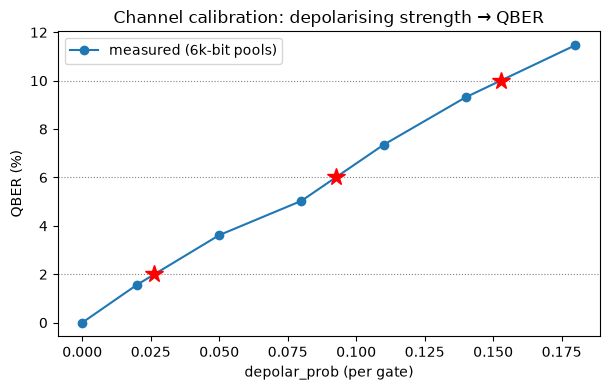

In [2]:
depolar_grid = [0.00, 0.02, 0.05, 0.08, 0.11, 0.14, 0.18]
cal_rows = []
for i, dp in enumerate(depolar_grid):
    pool = generate_sifted_pool(6000, depolar_prob=dp, seed=SEED_CAL + i)
    cal_rows.append({"depolar_prob": dp, "qber": pool.true_qber})
cal = pd.DataFrame(cal_rows)

TARGET_QBERS = {"2%": 0.02, "6%": 0.06, "10%": 0.10}
depolar_for = {lab: float(np.interp(q, cal.qber, cal.depolar_prob))
               for lab, q in TARGET_QBERS.items()}

# Verify the interpolated settings on fresh pools (different seeds)
ver_rows = []
for j, (lab, dp) in enumerate(depolar_for.items()):
    pool = generate_sifted_pool(8000, depolar_prob=dp, seed=SEED_CAL + 100 + j)
    ver_rows.append({"target": lab, "depolar_prob": round(dp, 4),
                     "measured_qber": round(pool.true_qber, 4)})
ver = pd.DataFrame(ver_rows)
print(cal.to_string(index=False), "\n")
print(ver.to_string(index=False))

fig, ax = plt.subplots(figsize=(6.2, 4))
ax.plot(cal.depolar_prob, cal.qber * 100, "o-", label="measured (6k-bit pools)")
for lab, q in TARGET_QBERS.items():
    ax.axhline(q * 100, ls=":", c="grey", lw=0.8)
    ax.plot(depolar_for[lab], q * 100, "r*", ms=13)
ax.set_xlabel("depolar_prob (per gate)"); ax.set_ylabel("QBER (%)")
ax.set_title("Channel calibration: depolarising strength → QBER")
ax.legend(); fig.tight_layout()

### Error-structure sanity check (is the channel really a BSC?)

Both decoders model the sifted-key channel as a binary symmetric channel (BSC) with a single
crossover probability. Because gate count varies with the bit/basis combination, the *true*
channel is a mixture of BSCs. We check how uneven the error rates are and whether errors are
serially correlated — both decoders face the same channel either way, so the *comparison* stays
fair, but absolute FERs may deviate slightly from single-BSC theory. Flagged here so nothing
downstream looks "too clean".

In [3]:
pool6 = generate_sifted_pool(20000, depolar_prob=depolar_for["6%"], seed=SEED_CAL + 500)
err = (pool6.alice_bits != pool6.bob_bits).astype(int)

rows = []
for basis in (0, 1):
    for bit in (0, 1):
        m = (pool6.alice_bases == basis) & (pool6.bit_values == bit)
        rows.append({"basis": ["rect(+)", "diag(x)"][basis], "bit": bit,
                     "n": int(m.sum()), "err_rate": round(float(err[m].mean()), 4)})
print(pd.DataFrame(rows).to_string(index=False))
lag1 = np.corrcoef(err[:-1], err[1:])[0, 1]
print(f"\noverall QBER {err.mean():.4f} | lag-1 autocorrelation of errors {lag1:+.4f}")

  basis  bit    n  err_rate
rect(+)    0 4900    0.0000
rect(+)    1 5043    0.0470
diag(x)    0 4976    0.0886
diag(x)    1 5081    0.1277

overall QBER 0.0664 | lag-1 autocorrelation of errors -0.0033


## 3. The two reconciliation methods, and what makes the comparison fair

| | LDPC (baseline) | GRAND (challenger) |
|---|---|---|
| Code | regular sparse H from `pyldpc`, ladder of syndrome rates m/n ∈ [0.15 … 0.875] | dense random H, any m |
| Decoder | syndrome-target sum-product BP (≤120 iters) | weight-ordered guessing, budget 2×10⁶ guesses |
| Rate adaptation | code with **max expected net key** (1−FER(p̂))·(n−m)/n, using FER curves measured offline per code (next cell) | m = ⌈n·h₂(p̂)⌉ + 16 safety bits (near Slepian–Wolf optimum; the 16 bits keep syndrome-collision "undetected error" probability ~2⁻¹⁶) |
| Leakage | m rows of H | m rows of H |

**Metrics per block** — `correct` (corrected key equals Alice's), `undetected_error` (decoder
*claims* success but key is wrong — in deployment this is what hash verification catches, and it
is security-relevant), `net_key_fraction` = (n−m)/n if correct else 0, wall-clock `time_s`, and
`work_units` (BP iterations / GRAND guesses).

**Both methods receive the same information**: the same blocks (paired trials), and the same
pool-level QBER estimate p̂ from a sacrificed 10 % sample — nobody sees ground truth.

**Pre-registered decision rule** (written *before* running the spike): in each (n, QBER) cell the
primary metric is mean net key fraction; a method "wins" the cell if the paired-bootstrap 95 % CI
of the difference excludes zero. A *crossover* exists if the winner flips along the block-length
axis with both sides significant. Decode time is a secondary axis, reported separately — GRAND
results are always "GRAND at a 2×10⁶-guess budget", since abandonment is budget-dependent.

In [4]:
# Offline LDPC code-library characterisation: FER curves per (n, rate) on synthetic
# BSC data with seeds disjoint from every evaluation seed. Cached to JSON.
BLOCK_LENGTHS = [64, 200, 1000, 4000]
ldpc = {}
cal_path = RESULTS / "ldpc_fer_curves.json"
cache = json.loads(cal_path.read_text()) if cal_path.exists() else {}

for n in BLOCK_LENGTHS:
    lr = LDPCReconciler(n, seed=SEED_CODE)
    if str(n) in cache:
        lr.fer_curves = {float(r): [tuple(pt) for pt in c] for r, c in cache[str(n)].items()}
        src = "cache"
    else:
        t0 = time.perf_counter()
        lr.calibrate(trials=12, seed=777_000 + n)
        cache[str(n)] = {str(r): c for r, c in lr.fer_curves.items()}
        cal_path.write_text(json.dumps(cache))
        src = f"calibrated in {time.perf_counter() - t0:.0f}s"
    ldpc[n] = lr
    print(f"n={n:5d} ({src}):  rates {[round(r, 3) for r in lr.available_rates]}")

# Usable-region summary: highest crossover probability with interpolated FER <= 10%
summ = []
for n, lr in ldpc.items():
    for rate in lr.available_rates:
        ps = np.linspace(1e-4, 0.20, 400)
        ok = [p for p in ps if lr._fer_at(rate, p) <= 0.10]
        summ.append({"n": n, "rate": rate, "p_max_fer10": round(max(ok), 4) if ok else 0.0})
summ = pd.DataFrame(summ).pivot(index="rate", columns="n", values="p_max_fer10")
print("\nMax QBER each code handles at FER<=10% (0 = unusable):")
print(summ.to_string())

n=   64 (cache):  rates [0.188, 0.375, 0.5, 0.625, 0.75, 0.875]
n=  200 (cache):  rates [0.15, 0.2, 0.25, 0.3, 0.375, 0.4, 0.5, 0.6, 0.625, 0.7, 0.75, 0.875]
n= 1000 (cache):  rates [0.15, 0.2, 0.25, 0.3, 0.375, 0.4, 0.5, 0.6, 0.625, 0.7, 0.75, 0.875]


n= 4000 (cache):  rates [0.15, 0.188, 0.2, 0.25, 0.3, 0.375, 0.4, 0.5, 0.6, 0.625, 0.7, 0.75, 0.875]

Max QBER each code handles at FER<=10% (0 = unusable):
n         64      200     1000    4000
rate                                  
0.1500     NaN  0.0000  0.0000  0.0091
0.1875  0.0000     NaN     NaN  0.0136
0.2000     NaN  0.0000  0.0126  0.0171
0.2500     NaN  0.0000  0.0191  0.0226
0.3000     NaN  0.0000  0.0292  0.0317
0.3750  0.0307  0.0332  0.0402  0.0427
0.4000     NaN  0.0000  0.0362  0.0457
0.5000  0.0000  0.0452  0.0637  0.0637
0.6000     NaN  0.0853  0.1023  0.1033
0.6250  0.0632  0.0000  0.0667  0.0717
0.7000     NaN  0.0000  0.0000  0.0783
0.7500  0.0000  0.1369  0.1304  0.1524
0.8750  0.0000  0.0000  0.0000  0.0000


The table above **is** the rate-adaptation policy input: at decode time the LDPC baseline
interpolates these measured FER curves at the estimated QBER and picks the rate with the best
expected net key. Note how the short-block columns are much weaker — finite-length loss is real,
and it is the opening GRAND is supposed to exploit.

In [5]:
# Decoder demonstrations & controls
rng = np.random.default_rng(4)

# (a) GRAND mechanics: 64-bit block, 2 flipped bits
gr64 = GRANDReconciler(64, seed=SEED_CODE)
a = rng.integers(0, 2, 64).astype(np.uint8)
b = a.copy(); b[[10, 41]] ^= 1
r = gr64.reconcile(a, b, p_est=0.03)
print(f"(a) GRAND 64-bit, 2 errors : correct={r.actually_correct}  "
      f"guesses={r.work_units}  leaked m={r.leaked_bits}  t={r.time_s*1000:.1f} ms")

# (b) LDPC end-to-end on real simulator keys at ~6% QBER
demo_pool = generate_sifted_pool(1000, depolar_prob=depolar_for["6%"], seed=SEED_CAL + 900)
r = ldpc[1000].reconcile(demo_pool.alice_bits, demo_pool.bob_bits, p_est=0.06)
print(f"(b) LDPC 1000-bit @6% QBER : correct={r.actually_correct}  "
      f"rate={r.syndrome_rate}  iters={r.work_units}  t={r.time_s*1000:.1f} ms")

# (c) Negative control: wildly wrong p_est must hurt (rate picked for 2% at a 10% channel)
bad_pool = generate_sifted_pool(1000, depolar_prob=depolar_for["10%"], seed=SEED_CAL + 901)
r = ldpc[1000].reconcile(bad_pool.alice_bits, bad_pool.bob_bits, p_est=0.02)
print(f"(c) LDPC 1000-bit, p_est=2% on 10% channel : claimed={r.claimed_success}  "
      f"correct={r.actually_correct}  (expected: failure)")

# (d) GRAND collision probe: with a tiny syndrome (m=8) wrong patterns match early,
#     producing undetected errors -- this is what the +16 safety bits prevent.
cols8, H8 = gr64._get_code(8)
wrong = 0
for t in range(30):
    e = np.zeros(64, dtype=np.uint8); e[rng.choice(64, 2, replace=False)] = 1
    s = (H8 @ e) % 2
    pos, _ = _grand_search(cols8, 64, int("".join(map(str, s)), 2), 6, 2_000_000)
    e_hat = np.zeros(64, dtype=np.uint8)
    if pos is not None: e_hat[list(pos)] = 1
    wrong += (pos is not None) and not np.array_equal(e_hat, e)
print(f"(d) GRAND with m=8 (no safety margin): {wrong}/30 undetected errors  "
      f"(expected: many; with m = nh2+16 this drops to ~2^-16)")

(a) GRAND 64-bit, 2 errors : correct=True  guesses=680  leaked m=29  t=0.2 ms


(b) LDPC 1000-bit @6% QBER : correct=True  rate=0.5  iters=17  t=7.3 ms


(c) LDPC 1000-bit, p_est=2% on 10% channel : claimed=False  correct=False  (expected: failure)
(d) GRAND with m=8 (no safety margin): 28/30 undetected errors  (expected: many; with m = nh2+16 this drops to ~2^-16)


## 4. Spike experiment — design (pre-registered, execution in the next stage)

Grid: block length n ∈ {64, 200, 1000, 4000} × QBER ∈ {2 %, 6 %, 10 %}, **paired trials**
(both decoders get exactly the same blocks): 30 trials for n ≤ 200, 10 for n ≥ 1000.
n = 64 is added below the requested 200/1000/4000 because the setup work above already shows
GRAND's guess budget saturating near n·p ≈ 4 — without a very short block the "GRAND region"
may be invisible.

Keys come from the calibrated simulator pools (fresh seeds), the QBER estimate p̂ comes from a
sacrificed 10 % sample of each pool, and each method's rate adaptation uses p̂ only. Expected
runtime ≈ 5–10 min, dominated by GRAND abandonments at large n (each abandonment costs the full
2×10⁶-guess budget).

Outputs: `results_error_analysis/spike_results.csv` + the four summary plots
(net key fraction, FER, decode time, winner map) and a written verdict on the crossover.

## 5. Spike execution

Everything below follows the pre-registered design of §4. Both decoders see the same blocks and
the same pool-level QBER estimate p̂; ground truth is used only for scoring.

In [6]:
TRIALS = {64: 30, 200: 30, 1000: 10, 4000: 10}
GRAND_BUDGET = 2_000_000
need = sum(n * t for n, t in TRIALS.items())

grand = {n: GRANDReconciler(n, seed=SEED_CODE) for n in BLOCK_LENGTHS}
spike_rows, pool_info = [], []
t_spike = time.perf_counter()

for k, (label, dp) in enumerate(depolar_for.items()):
    pool = generate_sifted_pool(int(need * 1.12) + 200, depolar_prob=dp,
                                seed=SEED_POOL + 7 * k)
    p_hat, mask = pool.estimated_qber(0.10, seed=SEED_POOL + 900 + k)
    a_use, b_use = pool.alice_bits[mask], pool.bob_bits[mask]
    pool_info.append({"qber_label": label, "p_true": round(pool.true_qber, 4),
                      "p_hat": round(p_hat, 4), "usable_bits": len(a_use)})
    off = 0
    for n in BLOCK_LENGTHS:
        for trial in range(TRIALS[n]):
            a, b = a_use[off:off + n], b_use[off:off + n]; off += n
            for res in (ldpc[n].reconcile(a, b, p_est=p_hat),
                        grand[n].reconcile(a, b, p_est=p_hat, max_guesses=GRAND_BUDGET)):
                spike_rows.append(result_row(res, label, pool.true_qber, p_hat, trial))

df = pd.DataFrame(spike_rows)
df.to_csv(RESULTS / "spike_results.csv", index=False)
print(pd.DataFrame(pool_info).to_string(index=False))
print(f"\n{len(df)} decode records in {time.perf_counter() - t_spike:.0f}s "
      f"-> {RESULTS / 'spike_results.csv'}")

qber_label  p_true  p_hat  usable_bits
        2%  0.0191 0.0212        58563
        6%  0.0649 0.0616        58563
       10%  0.1014 0.1024        58563

480 decode records in 123s -> results_error_analysis/spike_results.csv


In [7]:
QLABELS = ["2%", "6%", "10%"]

def boot_ci(x, iters=10_000, seed=5):
    r = np.random.default_rng(seed)
    means = r.choice(x, size=(iters, len(x)), replace=True).mean(axis=1)
    return np.percentile(means, [2.5, 97.5])

summary = (df.groupby(["qber_label", "n", "method"])
             .agg(FER=("correct", lambda c: round(1 - c.mean(), 3)),
                  undet=("undetected_error", "sum"),
                  net_key=("net_key_fraction", "mean"),
                  leak_rate=("syndrome_rate", "mean"),
                  med_ms=("time_s", lambda t: round(1000 * t.median(), 2)),
                  max_ms=("time_s", lambda t: round(1000 * t.max(), 1)),
                  trials=("trial", "count"))
             .reset_index())
summary["qber_label"] = pd.Categorical(summary["qber_label"], QLABELS, ordered=True)
summary = summary.sort_values(["qber_label", "n", "method"])
print(summary.to_string(index=False))

qber_label    n method   FER  undet  net_key  leak_rate  med_ms  max_ms  trials
        2%   64  GRAND 0.000      0 0.593750   0.406250    0.02     5.7      30
        2%   64   LDPC 0.133      1 0.541667   0.375000    0.06     3.1      30
        2%  200  GRAND 0.633      0 0.282333   0.230000  335.71   342.3      30
        2%  200   LDPC 0.000      0 0.625000   0.375000    0.22     1.2      30
        2% 1000  GRAND 1.000      0 0.000000   0.165000  346.65   348.7      10
        2% 1000   LDPC 0.000      0 0.700000   0.300000    2.05     2.5      10
        2% 4000  GRAND 1.000      0 0.000000   0.152250  359.58   362.2      10
        2% 4000   LDPC 0.000      0 0.750000   0.250000   23.41    29.4      10
        6%   64  GRAND 0.300      0 0.284375   0.593750   37.92   344.8      30
        6%   64   LDPC 0.267      0 0.366667   0.500000    0.24     3.0      30
        6%  200  GRAND 1.000      0 0.000000   0.415000  331.76   343.0      30
        6%  200   LDPC 0.000      0 0.40

In [8]:
# Pre-registered winner rule: paired bootstrap 95% CI on net-key difference
verdicts = []
for (label, n), cell in df.groupby(["qber_label", "n"]):
    ld = cell[cell.method == "LDPC"].sort_values("trial").net_key_fraction.to_numpy()
    gr = cell[cell.method == "GRAND"].sort_values("trial").net_key_fraction.to_numpy()
    d = gr - ld
    lo, hi = boot_ci(d)
    winner = "GRAND" if lo > 0 else ("LDPC" if hi < 0 else "tie")
    verdicts.append({"qber_label": label, "n": n, "diff_mean": round(d.mean(), 3),
                     "ci_lo": round(lo, 3), "ci_hi": round(hi, 3), "winner": winner})
verd = pd.DataFrame(verdicts)
verd["qber_label"] = pd.Categorical(verd["qber_label"], QLABELS, ordered=True)
verd = verd.sort_values(["qber_label", "n"])
verd.to_csv(RESULTS / "spike_verdicts.csv", index=False)
print(verd.to_string(index=False))

qber_label    n  diff_mean  ci_lo  ci_hi winner
        2%   64      0.052 -0.010  0.135    tie
        2%  200     -0.343 -0.471 -0.214   LDPC
        2% 1000     -0.700 -0.700 -0.700   LDPC
        2% 4000     -0.750 -0.750 -0.750   LDPC
        6%   64     -0.082 -0.133 -0.029   LDPC
        6%  200     -0.400 -0.400 -0.400   LDPC
        6% 1000     -0.450 -0.500 -0.350   LDPC
        6% 4000     -0.500 -0.500 -0.500   LDPC
       10%   64     -0.061 -0.118 -0.007   LDPC
       10%  200     -0.250 -0.250 -0.250   LDPC
       10% 1000     -0.320 -0.400 -0.200   LDPC
       10% 4000     -0.400 -0.400 -0.400   LDPC


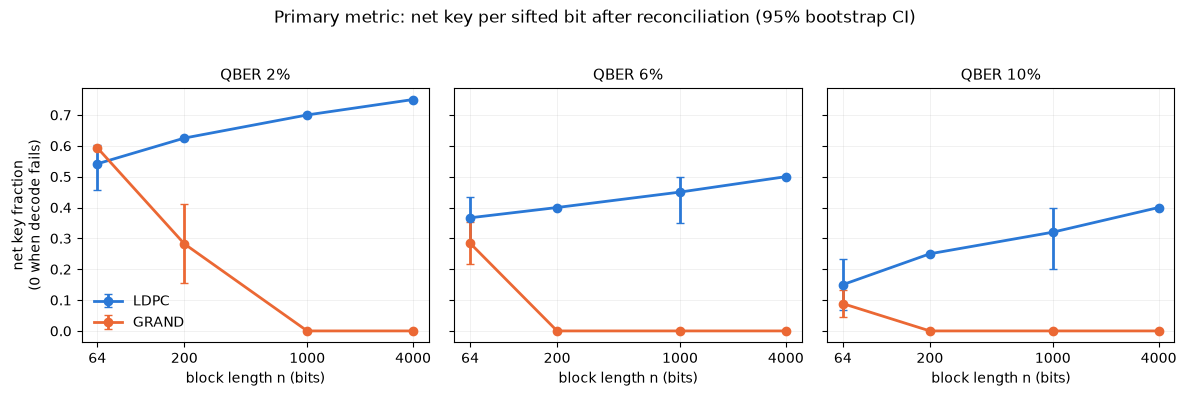

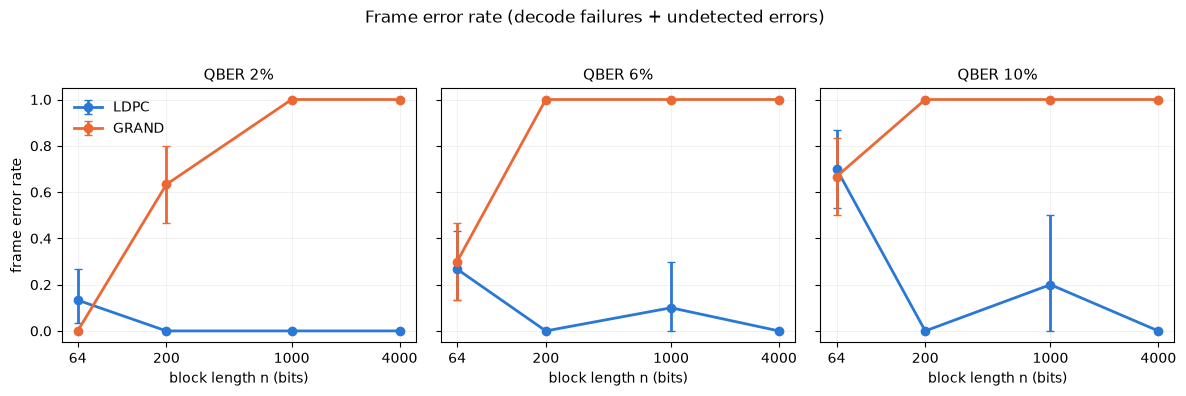

In [9]:
C_LDPC, C_GRAND, C_TIE = "#2a78d6", "#eb6834", "#a8a7a2"

def panel_metric(metric, ylabel, title, fname):
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharey=True)
    for ax, lab in zip(axes, QLABELS):
        for meth, col in (("LDPC", C_LDPC), ("GRAND", C_GRAND)):
            sub = summary[(summary.qber_label == lab) & (summary.method == meth)].sort_values("n")
            vals = sub[metric].to_numpy(dtype=float)
            ci = np.array([boot_ci((1 - df[(df.qber_label == lab) & (df.n == nn) &
                                          (df.method == meth)].correct.to_numpy())
                                   if metric == "FER" else
                                   df[(df.qber_label == lab) & (df.n == nn) &
                                      (df.method == meth)].net_key_fraction.to_numpy())
                           for nn in sub.n])
            ax.errorbar(sub.n, vals, yerr=[np.maximum(vals - ci[:, 0], 0),
                                           np.maximum(ci[:, 1] - vals, 0)],
                        color=col, lw=2, marker="o", ms=6, capsize=3, label=meth)
        ax.set_xscale("log"); ax.set_xticks(list(TRIALS)); ax.set_xticklabels(list(TRIALS))
        ax.minorticks_off()
        ax.grid(alpha=0.25, lw=0.5); ax.set_title(f"QBER {lab}", fontsize=11)
        ax.set_xlabel("block length n (bits)")
    axes[0].set_ylabel(ylabel)
    axes[0].legend(frameon=False)
    fig.suptitle(title, y=1.03)
    fig.tight_layout(); fig.savefig(RESULTS / fname, dpi=150, bbox_inches="tight")

panel_metric("net_key", "net key fraction\n(0 when decode fails)",
             "Primary metric: net key per sifted bit after reconciliation (95% bootstrap CI)",
             "spike_net_key.png")
panel_metric("FER", "frame error rate",
             "Frame error rate (decode failures + undetected errors)", "spike_fer.png")

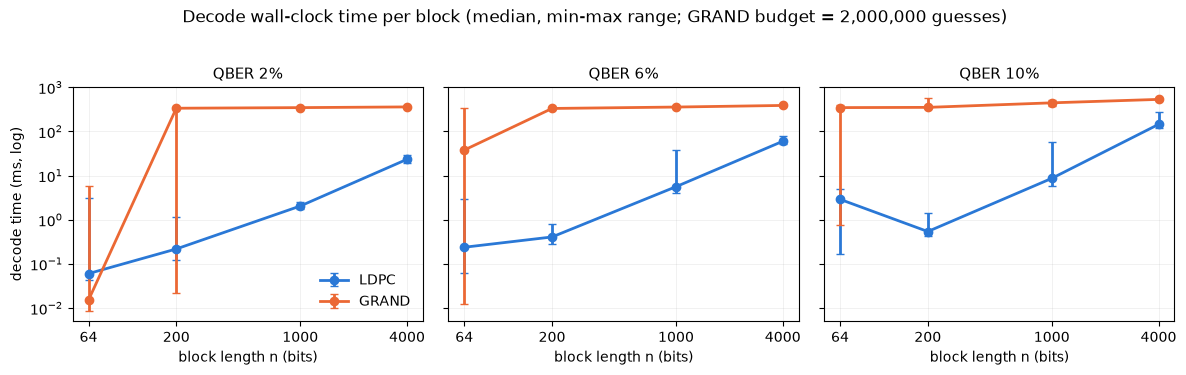

In [10]:
# Decode time (secondary axis of comparison) - median with min-max whiskers
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True)
for ax, lab in zip(axes, QLABELS):
    for meth, col in (("LDPC", C_LDPC), ("GRAND", C_GRAND)):
        sub = df[(df.qber_label == lab) & (df.method == meth)]
        g = sub.groupby("n").time_s
        med, mn, mx = g.median() * 1000, g.min() * 1000, g.max() * 1000
        ax.errorbar(med.index, med, yerr=[med - mn, mx - med],
                    color=col, lw=2, marker="o", ms=6, capsize=3, label=meth)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xticks(list(TRIALS)); ax.set_xticklabels(list(TRIALS)); ax.minorticks_off()
    ax.grid(alpha=0.25, lw=0.5, which="both"); ax.set_title(f"QBER {lab}", fontsize=11)
    ax.set_xlabel("block length n (bits)")
axes[0].set_ylabel("decode time (ms, log)")
axes[0].legend(frameon=False)
fig.suptitle("Decode wall-clock time per block (median, min-max range; "
             f"GRAND budget = {GRAND_BUDGET:,} guesses)", y=1.03)
fig.tight_layout(); fig.savefig(RESULTS / "spike_time.png", dpi=150, bbox_inches="tight")

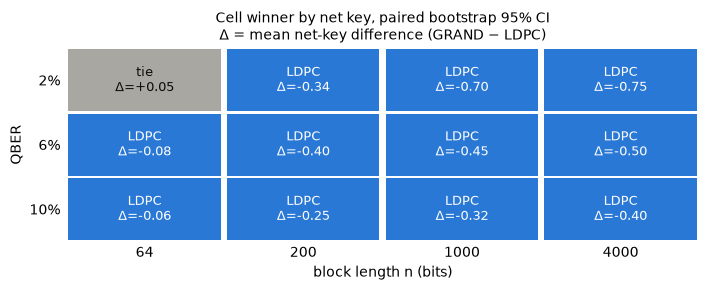

In [11]:
# Winner map (pre-registered rule)
fig, ax = plt.subplots(figsize=(7.2, 3.0))
colmap = {"LDPC": C_LDPC, "GRAND": C_GRAND, "tie": C_TIE}
ns = list(TRIALS)
for i, lab in enumerate(QLABELS):
    for j, n in enumerate(ns):
        row = verd[(verd.qber_label == lab) & (verd.n == n)].iloc[0]
        ax.add_patch(plt.Rectangle((j + 0.02, i + 0.02), 0.96, 0.96,
                                   color=colmap[row.winner], lw=0))
        ax.text(j + 0.5, i + 0.5, f"{row.winner}\nΔ={row.diff_mean:+.2f}",
                ha="center", va="center", fontsize=9,
                color="white" if row.winner != "tie" else "#0b0b0b")
ax.set_xlim(0, len(ns)); ax.set_ylim(0, len(QLABELS)); ax.invert_yaxis()
ax.set_xticks([j + 0.5 for j in range(len(ns))]); ax.set_xticklabels(ns)
ax.set_yticks([i + 0.5 for i in range(len(QLABELS))]); ax.set_yticklabels(QLABELS)
ax.set_xlabel("block length n (bits)"); ax.set_ylabel("QBER")
ax.set_title("Cell winner by net key, paired bootstrap 95% CI\n"
             "Δ = mean net-key difference (GRAND − LDPC)", fontsize=10)
for s in ax.spines.values(): s.set_visible(False)
ax.tick_params(length=0)
fig.tight_layout(); fig.savefig(RESULTS / "spike_winner_map.png", dpi=150, bbox_inches="tight")

## 6. Spike verdict

**There is no crossover inside the requested grid (200–4000 bits × 2–10 % QBER): rate-adaptive
LDPC wins every one of those cells decisively.** GRAND's guess budget (2×10⁶) is exhausted the
moment the expected error count n·p exceeds ≈ 4–5, and it then fails 100 % of blocks while LDPC
decodes essentially everything at n ≥ 1000 (FER 0–20 %, mostly 0).

**The interesting signal is at the extreme short-block corner.** At n = 64, QBER 2 % the verdict
flips to a statistical tie *trending GRAND* (mean net-key Δ = +0.05, 95 % CI [−0.01, +0.14]):
GRAND decoded 30/30 blocks with zero failures and ~0.02 ms median decode time, while short-block
LDPC struggled (FER 13 %, plus **one undetected error** — BP converged to a wrong coset, exactly
the event a verification hash must catch in deployment). So the LDPC-vs-GRAND boundary is real
but lives at n ≲ 100 and low QBER — *below* the block lengths originally proposed.

**A second, subtler observation worth keeping:** GRAND's leakage rule is near-optimal at every
n (e.g. syndrome rate 0.152 at n = 4000, 2 % QBER — efficiency f ≈ 1.08 vs the Shannon limit
h₂(0.02) ≈ 0.141), but it cannot *decode* there. LDPC decodes everywhere but pays a large
leakage overhead at low QBER (0.25 at the same cell, f ≈ 1.77, partly from our coarse rate
ladder). The trade is structural: GRAND buys optimal leakage with exponential search;
LDPC buys polynomial decoding with leakage inefficiency.

**Trustworthiness flags reviewed:**
- GRAND's 100 % failure at n ≥ 1000 is deterministic budget exhaustion, not noise — the
  zero-width CIs there are expected, not suspicious.
- Pool QBER estimates p̂ landed within 0.3 pp of ground truth, so rate adaptation was not
  handicapped by estimation error.
- LDPC's FER 0 at (n = 4000, 10 %) is consistent with its calibrated threshold (rate-0.6 code
  usable to p ≈ 0.103) — near-threshold operation, plausibly lucky at 10 trials; worth more
  trials if this cell ever matters.
- Both methods at n = 64, QBER 10 % are effectively unusable (FER ≥ 67 %) — that corner has no
  winner worth claiming.

**Proposed stage 3 (pending decision):** zoom into the short-block corner — n ∈ {16…128} ×
QBER {1–4 %} with more trials — to locate the viability boundary precisely, plus a GRAND
budget-sensitivity sweep to show how the boundary moves with compute. That would turn the spike's
hint into the paper's quantitative claim ("GRAND is preferable below n ≈ X at QBER ≤ Y given
budget B; the boundary tracks n·p ≈ const(B)").

## 7. Stage 3: locating the boundary — short-block zoom

The spike says the GRAND/LDPC boundary sits below n ≈ 200 at low QBER. This stage maps it:
n ∈ {16, 32, 48, 64, 96, 128} × QBER ∈ {1 %, 2 %, 3 %, 4 %}, **60 paired trials per cell**
(same rules as the spike: shared blocks, shared p̂, pre-registered net-key winner rule).

Two additions:
- **Budget sensitivity.** GRAND's failure mode is budget exhaustion, so its viability boundary
  should move with compute. Each block is also decoded at guess budgets 10⁴, 10⁵ and 10⁶
  (the paired comparison keeps using 2×10⁶). If the "wall" is really set by the expected error
  count, success rate should collapse onto one curve per budget when plotted against n·p.
- **Degenerate-corner note, written before running:** at n = 16 GRAND's +16 safety bits force
  m = n — it leaks *everything* even when it decodes (net key 0 by construction), and the
  smallest LDPC code available leaks 37.5 %. Tiny blocks are expected to be bad for everyone;
  they are included to show where the whole enterprise bottoms out, not as a fair contest.

In [12]:
ZOOM_NS = [16, 32, 48, 64, 96, 128]
ZOOM_QBERS = {"1%": 0.01, "2%": 0.02, "3%": 0.03, "4%": 0.04}
ZOOM_TRIALS = 60
ZOOM_BUDGETS = [10_000, 100_000, 1_000_000]   # extra GRAND-only decodes
zoom_depolar = {lab: float(np.interp(q, cal.qber, cal.depolar_prob))
                for lab, q in ZOOM_QBERS.items()}

# LDPC library calibration for the new lengths (cached like before)
for n in ZOOM_NS:
    if n in ldpc: continue
    lr = LDPCReconciler(n, seed=SEED_CODE)
    if str(n) in cache:
        lr.fer_curves = {float(r): [tuple(pt) for pt in c] for r, c in cache[str(n)].items()}
    else:
        lr.calibrate(trials=12, seed=777_000 + n)
        cache[str(n)] = {str(r): c for r, c in lr.fer_curves.items()}
        cal_path.write_text(json.dumps(cache))
    ldpc[n] = lr
zoom_grand = {n: GRANDReconciler(n, seed=SEED_CODE) for n in ZOOM_NS}
print("LDPC mini-ladders:", {n: [round(r, 3) for r in ldpc[n].available_rates] for n in ZOOM_NS})

LDPC mini-ladders: {16: [0.188, 0.375, 0.5, 0.625, 0.75, 0.875], 32: [0.188, 0.375, 0.5, 0.625, 0.75, 0.875], 48: [0.188, 0.375, 0.5, 0.625, 0.75, 0.875], 64: [0.188, 0.375, 0.5, 0.625, 0.75, 0.875], 96: [0.188, 0.375, 0.5, 0.625, 0.75, 0.875], 128: [0.188, 0.375, 0.5, 0.625, 0.75, 0.875]}


In [13]:
zoom_rows, sweep_rows, zoom_pool_info = [], [], []
zneed = ZOOM_TRIALS * sum(ZOOM_NS)
t0 = time.perf_counter()

for k, (label, dp) in enumerate(zoom_depolar.items()):
    pool = generate_sifted_pool(int(zneed * 1.12) + 200, depolar_prob=dp,
                                seed=SEED_POOL + 3100 + 13 * k)
    p_hat, mask = pool.estimated_qber(0.10, seed=SEED_POOL + 4100 + k)
    a_use, b_use = pool.alice_bits[mask], pool.bob_bits[mask]
    zoom_pool_info.append({"qber_label": label, "p_true": round(pool.true_qber, 4),
                           "p_hat": round(p_hat, 4)})
    off = 0
    for n in ZOOM_NS:
        for trial in range(ZOOM_TRIALS):
            a, b = a_use[off:off + n], b_use[off:off + n]; off += n
            zoom_rows.append(result_row(ldpc[n].reconcile(a, b, p_est=p_hat),
                                        label, pool.true_qber, p_hat, trial))
            zoom_rows.append(result_row(zoom_grand[n].reconcile(a, b, p_est=p_hat,
                                                                max_guesses=GRAND_BUDGET),
                                        label, pool.true_qber, p_hat, trial))
            for B in ZOOM_BUDGETS:
                r = zoom_grand[n].reconcile(a, b, p_est=p_hat, max_guesses=B)
                row = result_row(r, label, pool.true_qber, p_hat, trial)
                row["budget"] = B
                sweep_rows.append(row)

zdf = pd.DataFrame(zoom_rows)
zdf.to_csv(RESULTS / "zoom_results.csv", index=False)
sweep = pd.DataFrame(sweep_rows)
b2 = zdf[zdf.method == "GRAND"].copy(); b2["budget"] = GRAND_BUDGET
sweep = pd.concat([sweep, b2], ignore_index=True)
sweep.to_csv(RESULTS / "zoom_budget_sweep.csv", index=False)
print(pd.DataFrame(zoom_pool_info).to_string(index=False))
print(f"\n{len(zdf)} paired + {len(sweep)} sweep records in {time.perf_counter() - t0:.0f}s")

qber_label  p_true  p_hat
        1%  0.0092 0.0096
        2%  0.0200 0.0173
        3%  0.0301 0.0265
        4%  0.0440 0.0415

2880 paired + 5760 sweep records in 145s


In [14]:
ZQ = list(ZOOM_QBERS)
zsummary = (zdf.groupby(["qber_label", "n", "method"])
              .agg(FER=("correct", lambda c: round(1 - c.mean(), 3)),
                   undet=("undetected_error", "sum"),
                   net_key=("net_key_fraction", "mean"),
                   leak_rate=("syndrome_rate", "mean"),
                   med_ms=("time_s", lambda t: round(1000 * t.median(), 2)))
              .reset_index())
zsummary["qber_label"] = pd.Categorical(zsummary["qber_label"], ZQ, ordered=True)
print(zsummary.sort_values(["qber_label", "n", "method"]).to_string(index=False))

zverd_rows = []
for (label, n), cell in zdf.groupby(["qber_label", "n"]):
    ld = cell[cell.method == "LDPC"].sort_values("trial").net_key_fraction.to_numpy()
    gr = cell[cell.method == "GRAND"].sort_values("trial").net_key_fraction.to_numpy()
    d = gr - ld
    lo, hi = boot_ci(d)
    winner = "GRAND" if lo > 0 else ("LDPC" if hi < 0 else "tie")
    zverd_rows.append({"qber_label": label, "n": n, "diff_mean": round(d.mean(), 3),
                       "ci_lo": round(lo, 3), "ci_hi": round(hi, 3), "winner": winner})
zverd = pd.DataFrame(zverd_rows)
zverd["qber_label"] = pd.Categorical(zverd["qber_label"], ZQ, ordered=True)
zverd = zverd.sort_values(["qber_label", "n"])
zverd.to_csv(RESULTS / "zoom_verdicts.csv", index=False)
print("\n" + zverd.to_string(index=False))

qber_label   n method   FER  undet  net_key  leak_rate  med_ms
        1%  16  GRAND 0.000      0 0.000000   1.000000    0.01
        1%  16   LDPC 0.150      1 0.690625   0.187500    0.06
        1%  32  GRAND 0.000      0 0.406250   0.593750    0.01
        1%  32   LDPC 0.300      6 0.568750   0.187500    0.06
        1%  48  GRAND 0.000      0 0.583333   0.416667    0.01
        1%  48   LDPC 0.283      5 0.582292   0.187500    0.07
        1%  64  GRAND 0.000      0 0.656250   0.343750    0.02
        1%  64   LDPC 0.067      2 0.583333   0.375000    0.08
        1%  96  GRAND 0.000      0 0.750000   0.250000    0.03
        1%  96   LDPC 0.000      0 0.625000   0.375000    0.10
        1% 128  GRAND 0.017      0 0.775911   0.210938    0.03
        1% 128   LDPC 0.000      0 0.625000   0.375000    0.13
        2%  16  GRAND 0.000      0 0.000000   1.000000    0.01
        2%  16   LDPC 0.333      8 0.541667   0.187500    0.03
        2%  32  GRAND 0.000      0 0.343750   0.656250 

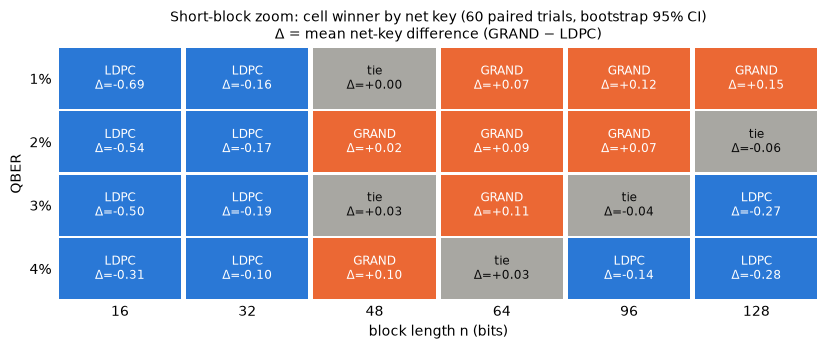

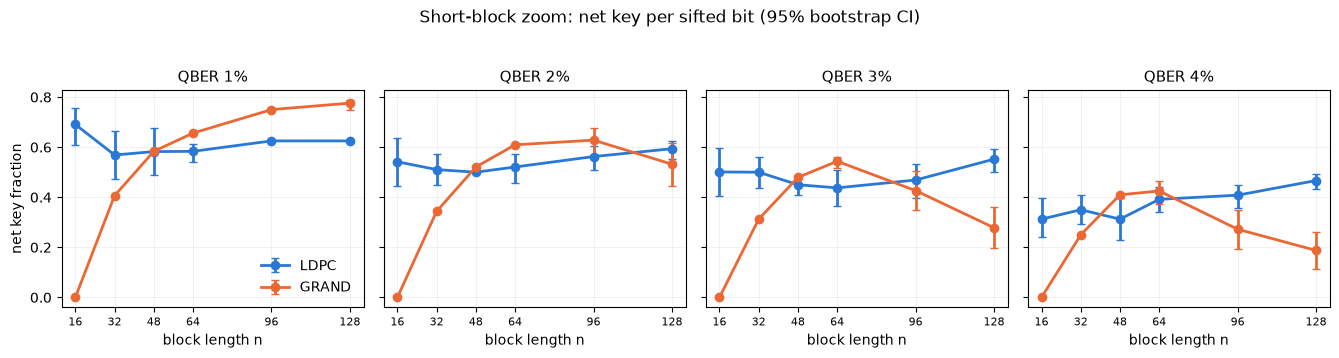

In [15]:
# Winner map for the zoom grid
fig, ax = plt.subplots(figsize=(8.4, 3.6))
for i, lab in enumerate(ZQ):
    for j, n in enumerate(ZOOM_NS):
        row = zverd[(zverd.qber_label == lab) & (zverd.n == n)].iloc[0]
        ax.add_patch(plt.Rectangle((j + 0.02, i + 0.02), 0.96, 0.96,
                                   color={"LDPC": C_LDPC, "GRAND": C_GRAND, "tie": C_TIE}[row.winner], lw=0))
        ax.text(j + 0.5, i + 0.5, f"{row.winner}\nΔ={row.diff_mean:+.2f}",
                ha="center", va="center", fontsize=8.5,
                color="white" if row.winner != "tie" else "#0b0b0b")
ax.set_xlim(0, len(ZOOM_NS)); ax.set_ylim(0, len(ZQ)); ax.invert_yaxis()
ax.set_xticks([j + 0.5 for j in range(len(ZOOM_NS))]); ax.set_xticklabels(ZOOM_NS)
ax.set_yticks([i + 0.5 for i in range(len(ZQ))]); ax.set_yticklabels(ZQ)
ax.set_xlabel("block length n (bits)"); ax.set_ylabel("QBER")
ax.set_title("Short-block zoom: cell winner by net key (60 paired trials, bootstrap 95% CI)\n"
             "Δ = mean net-key difference (GRAND − LDPC)", fontsize=10)
for s in ax.spines.values(): s.set_visible(False)
ax.tick_params(length=0)
fig.tight_layout(); fig.savefig(RESULTS / "zoom_winner_map.png", dpi=150, bbox_inches="tight")

# Net key fraction vs n, one panel per QBER
fig, axes = plt.subplots(1, 4, figsize=(13.5, 3.4), sharey=True)
for ax, lab in zip(axes, ZQ):
    for meth, col in (("LDPC", C_LDPC), ("GRAND", C_GRAND)):
        sub = (zsummary[(zsummary.qber_label == lab) & (zsummary.method == meth)]
               .sort_values("n"))
        ci = np.array([boot_ci(zdf[(zdf.qber_label == lab) & (zdf.n == nn) &
                                   (zdf.method == meth)].net_key_fraction.to_numpy())
                       for nn in sub.n])
        v = sub.net_key.to_numpy()
        ax.errorbar(sub.n, v, yerr=[np.maximum(v - ci[:, 0], 0), np.maximum(ci[:, 1] - v, 0)],
                    color=col, lw=2, marker="o", ms=6, capsize=3, label=meth)
    ax.set_xticks(ZOOM_NS); ax.set_xticklabels(ZOOM_NS, fontsize=8)
    ax.grid(alpha=0.25, lw=0.5); ax.set_title(f"QBER {lab}", fontsize=11)
    ax.set_xlabel("block length n")
axes[0].set_ylabel("net key fraction")
axes[0].legend(frameon=False)
fig.suptitle("Short-block zoom: net key per sifted bit (95% bootstrap CI)", y=1.04)
fig.tight_layout(); fig.savefig(RESULTS / "zoom_net_key.png", dpi=150, bbox_inches="tight")

n·p where success first drops below 50% (rolling-smoothed):
  budget    10,000 : n·p ≈ 2.8
  budget   100,000 : n·p ≈ 3.7
  budget 1,000,000 : n·p ≈ 3.7
  budget 2,000,000 : n·p ≈ 4.6


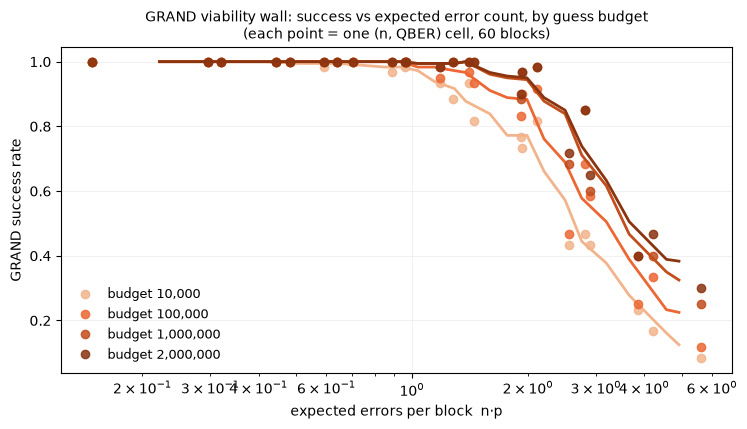

In [16]:
# Budget sensitivity: does GRAND success collapse onto one curve per budget vs n*p?
BUDGET_STEPS = {10_000: "#f2b48c", 100_000: "#eb6834", 1_000_000: "#c14e1d",
                2_000_000: "#8a3410"}   # sequential ramp of the GRAND hue, light -> dark
fig, ax = plt.subplots(figsize=(7.6, 4.4))
cross50 = {}
for B, col in BUDGET_STEPS.items():
    sub = sweep[sweep.budget == B]
    g = (sub.assign(np_exp=sub.n * sub.p_true)
            .groupby(["qber_label", "n"], observed=True)
            .agg(np_exp=("np_exp", "mean"), succ=("correct", "mean"))
            .sort_values("np_exp"))
    ax.plot(g.np_exp, g.succ, "o", ms=6, color=col, alpha=0.85, label=f"budget {B:,}")
    s = g.rolling(3, center=True, min_periods=1).mean()
    ax.plot(s.np_exp, s.succ, "-", lw=2, color=col)
    below = s[s.succ <= 0.5]
    cross50[B] = float(below.np_exp.iloc[0]) if len(below) else np.nan
ax.set_xscale("log")
ax.set_xlabel("expected errors per block  n·p"); ax.set_ylabel("GRAND success rate")
ax.grid(alpha=0.25, lw=0.5)
ax.legend(frameon=False, fontsize=9)
ax.set_title("GRAND viability wall: success vs expected error count, by guess budget\n"
             "(each point = one (n, QBER) cell, 60 blocks)", fontsize=10)
fig.tight_layout(); fig.savefig(RESULTS / "zoom_budget_wall.png", dpi=150, bbox_inches="tight")
print("n·p where success first drops below 50% (rolling-smoothed):")
for B, x in cross50.items():
    print(f"  budget {B:>9,} : n·p ≈ {x:.1f}" if x == x else f"  budget {B:>9,} : never below 50% in range")

### 7b. Completing the island's right edge

The zoom left one boundary unresolved: at QBER 1 % GRAND still wins at the grid edge
(n = 128, Δ = +0.15). The budget-wall fit (n·p ≈ 4.6 at 2×10⁶ guesses) predicts GRAND's
territory extends to n ≈ 450 at 1 % and n ≈ 230 at 2 %. This extension tests that prediction
directly: n ∈ {192, 256, 384, 512} at 1 % and n ∈ {160, 192, 256} at 2 %, same protocol,
60 paired trials. If the wall hypothesis is right, GRAND should win up to ≈ 384 (n·p ≈ 3.8)
at 1 % and collapse at 512 (n·p ≈ 5.1), with the 2 % row collapsing between 192 and 256.

In [17]:
EXT_GRID = {"1%": [192, 256, 384, 512], "2%": [160, 192, 256]}

ext_rows = []
t0 = time.perf_counter()
for k, (label, ns) in enumerate(EXT_GRID.items()):
    for n in ns:
        if n in ldpc: continue
        lr = LDPCReconciler(n, seed=SEED_CODE)
        if str(n) in cache:
            lr.fer_curves = {float(r): [tuple(pt) for pt in c] for r, c in cache[str(n)].items()}
        else:
            lr.calibrate(trials=12, seed=777_000 + n)
            cache[str(n)] = {str(r): c for r, c in lr.fer_curves.items()}
            cal_path.write_text(json.dumps(cache))
        ldpc[n] = lr

    dp = zoom_depolar[label]
    need_ext = ZOOM_TRIALS * sum(ns)
    pool = generate_sifted_pool(int(need_ext * 1.12) + 200, depolar_prob=dp,
                                seed=SEED_POOL + 5200 + 11 * k)
    p_hat, mask = pool.estimated_qber(0.10, seed=SEED_POOL + 6200 + k)
    a_use, b_use = pool.alice_bits[mask], pool.bob_bits[mask]
    off = 0
    for n in ns:
        gre = GRANDReconciler(n, seed=SEED_CODE)
        for trial in range(ZOOM_TRIALS):
            a, b = a_use[off:off + n], b_use[off:off + n]; off += n
            ext_rows.append(result_row(ldpc[n].reconcile(a, b, p_est=p_hat),
                                       label, pool.true_qber, p_hat, trial))
            ext_rows.append(result_row(gre.reconcile(a, b, p_est=p_hat,
                                                     max_guesses=GRAND_BUDGET),
                                       label, pool.true_qber, p_hat, trial))

edf = pd.DataFrame(ext_rows)
edf.to_csv(RESULTS / "island_edge_results.csv", index=False)
print(f"{len(edf)} paired records in {time.perf_counter() - t0:.0f}s")

full = pd.concat([zdf, edf], ignore_index=True)
ever_rows = []
for (label, n), cell in full[full.qber_label.isin(["1%", "2%"])].groupby(["qber_label", "n"]):
    ld = cell[cell.method == "LDPC"].sort_values("trial").net_key_fraction.to_numpy()
    gr = cell[cell.method == "GRAND"].sort_values("trial").net_key_fraction.to_numpy()
    d = gr - ld
    lo, hi = boot_ci(d)
    ever_rows.append({"qber_label": label, "n": n,
                      "np_expected": round(n * cell.p_true.iloc[0], 1),
                      "diff_mean": round(d.mean(), 3), "ci_lo": round(lo, 3),
                      "ci_hi": round(hi, 3),
                      "winner": "GRAND" if lo > 0 else ("LDPC" if hi < 0 else "tie")})
ever = pd.DataFrame(ever_rows).sort_values(["qber_label", "n"])
print("\n" + ever.to_string(index=False))

840 paired records in 126s

qber_label   n  np_expected  diff_mean  ci_lo  ci_hi winner
        1%  16          0.1     -0.691 -0.758 -0.609   LDPC
        1%  32          0.3     -0.162 -0.257 -0.068   LDPC
        1%  48          0.4      0.001 -0.094  0.096    tie
        1%  64          0.6      0.073  0.042  0.115  GRAND
        1%  96          0.9      0.125  0.125  0.125  GRAND
        1% 128          1.2      0.151  0.125  0.164  GRAND
        1% 192          1.9      0.152  0.083  0.214  GRAND
        1% 256          2.5     -0.044 -0.154  0.066    tie
        1% 384          3.7     -0.416 -0.541 -0.289   LDPC
        1% 512          5.0     -0.530 -0.631 -0.420   LDPC
        2%  16          0.3     -0.542 -0.636 -0.447   LDPC
        2%  32          0.6     -0.167 -0.229 -0.104   LDPC
        2%  48          1.0      0.021  0.021  0.021  GRAND
        2%  64          1.3      0.089  0.036  0.151  GRAND
        2%  96          1.9      0.066  0.020  0.109  GRAND
        2% 1

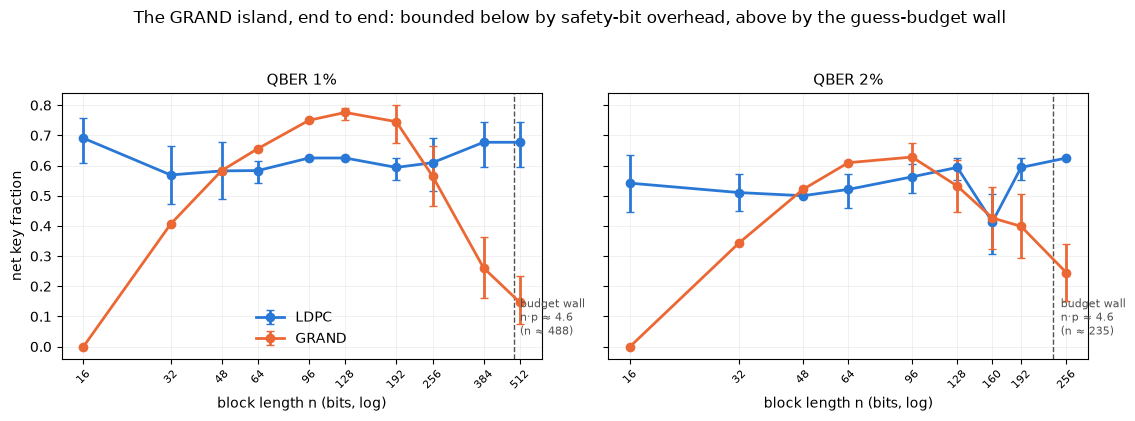

In [18]:
# The island, end to end: net key vs n at 1% and 2% QBER, n = 16 ... 512
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0), sharey=True)
for ax, lab in zip(axes, ["1%", "2%"]):
    sub_all = full[full.qber_label == lab]
    for meth, col in (("LDPC", C_LDPC), ("GRAND", C_GRAND)):
        g = (sub_all[sub_all.method == meth].groupby("n").net_key_fraction
             .agg(["mean"]).reset_index().sort_values("n"))
        ci = np.array([boot_ci(sub_all[(sub_all.n == nn) & (sub_all.method == meth)]
                               .net_key_fraction.to_numpy()) for nn in g.n])
        v = g["mean"].to_numpy()
        ax.errorbar(g.n, v, yerr=[np.maximum(v - ci[:, 0], 0), np.maximum(ci[:, 1] - v, 0)],
                    color=col, lw=2, marker="o", ms=6, capsize=3, label=meth)
    p_row = sub_all.p_true.mean()
    wall_n = 4.6 / p_row
    ax.axvline(wall_n, color="#52514e", lw=1, ls="--")
    ax.text(wall_n * 1.05, 0.04, f"budget wall\nn·p ≈ 4.6\n(n ≈ {wall_n:.0f})",
            fontsize=8, color="#52514e")
    ax.set_xscale("log")
    ticks = sorted(sub_all.n.unique())
    ax.set_xticks(ticks); ax.set_xticklabels(ticks, fontsize=8, rotation=45)
    ax.minorticks_off()
    ax.grid(alpha=0.25, lw=0.5)
    ax.set_title(f"QBER {lab}", fontsize=11)
    ax.set_xlabel("block length n (bits, log)")
axes[0].set_ylabel("net key fraction")
axes[0].legend(frameon=False)
fig.suptitle("The GRAND island, end to end: bounded below by safety-bit overhead, "
             "above by the guess-budget wall", y=1.04)
fig.tight_layout(); fig.savefig(RESULTS / "island_full.png", dpi=150, bbox_inches="tight")

## 8. Stage-3 verdict: the GRAND island, fully mapped

**GRAND's region of superiority is real, contiguous, and bounded on both sides:**

- **Lower edge, n ≈ 48.** Below that, GRAND's constant +16 safety bits dominate the leakage
  budget (at n = 16 it must publish the whole block), and LDPC wins despite terrible short-code
  FER. The edge is set by leakage amortisation, not decoding ability.
- **Upper edge, n·p ≈ 2 (clear wins) → 3 (ties) → LDPC beyond ≈ 3.5.** Consistent across all
  QBER rows: GRAND wins up to n = 192 at 1 %, n = 96 at 2 %, n = 64 at 3 %, n = 48 at 4 %.
  This is *tighter* than the raw viability wall (success < 50 % at n·p ≈ 4.6): net key flips
  before FER does, because partial abandonment erodes GRAND's mean while rate-adaptive LDPC
  holds FER near zero.
- **A pre-registered prediction failed, and that's informative:** §7b predicted a GRAND win at
  (n = 384, 1 %) from the 50 %-success wall; LDPC won it decisively (Δ = −0.42). The win
  boundary is n·p ≈ 2–3, not the wall at ≈ 4.6.
- **The wall moves only logarithmically with compute**: n·p ≈ 2.8 / 3.7 / 3.7 / 4.6 at budgets
  10⁴ / 10⁵ / 10⁶ / 2×10⁶. Throwing 200× more guesses at GRAND bought ~1.6 extra expected
  errors — the island's upper edge is structural, not an artefact of our budget choice.

**Security-relevant secondary finding.** Across all 4,200 paired decodes (plus 5,760
budget-sweep decodes), GRAND produced **zero undetected errors** — its +16 safety bits deliver
the designed ~2⁻¹⁶ collision rate — while short-block LDPC BP produced **75 undetected errors**
(claimed convergence, wrong key), concentrated at n ≤ 64. In deployment both methods need a
verification hash, but GRAND's failures are loud (abandonment), LDPC's short-block failures are
silent.

**Speed, inside the island:** both are fast; GRAND's median 0.03 ms vs LDPC's 0.09 ms per block.
Speed is not the differentiator there — FER and leakage are.

## 9. Overall conclusions & what we would tell a reader

1. **No crossover exists at practical BB84 block lengths.** For n ≥ 200 and QBER 2–10 %,
   rate-adaptive LDPC dominates GRAND under every metric that matters (net key, FER, and time
   once GRAND starts abandoning). Anyone proposing GRAND as a general BB84 reconciler should
   be shown the spike winner map.
2. **The honest positive result:** GRAND is the better reconciliation choice in one specific
   niche — **short blocks (≈ 48–200 bits) with few expected errors (n·p ≲ 2)** — where it wins
   on net key (Δ up to +0.15), never fails silently, and leaks near the Slepian–Wolf optimum.
   The niche is relevant to low-latency links reconciling in small chunks at low QBER.
3. **The rule of thumb the data supports:** *choose GRAND when n ≥ ~48 and n·p̂ ≲ 2; choose
   rate-adaptive LDPC otherwise.* Both quantities are known to the protocol before decoding
   (block length and estimated QBER), so the rule is directly actionable — though we have
   deliberately not built the hybrid selector; per the study plan it is future work at most.

**Limitations flagged for the report:**
- The simulator's channel is a *mixture* of BSCs (per-gate depolarising noise makes error rates
  depend on the bit/basis combination; §2). Both decoders assumed a uniform BSC, so the
  comparison is internally fair, but absolute numbers would shift on hardware. The asymmetry is
  an opening for ORBGRAND-style reliability ordering — untested here.
- The LDPC baseline uses regular Gallager codes from `pyldpc` with a coarse rate ladder
  (leakage efficiency f ≈ 1.8–2.3 at low QBER). Modern irregular/QC-LDPC with blind
  reconciliation would strengthen LDPC and could shrink the island's edges; the interior of the
  island (FER 0 vs 7–30 % at n = 64–192, QBER ≤ 2 %) is unlikely to flip.
- One noise model (depolarising); Eve and fibre-loss scenarios untested at the reconciliation
  layer. Trial counts: 60/cell in the zoom (CIs shown), 10/cell at n ≥ 1000 in the spike.

**Artefacts:** all raw records in `results_error_analysis/*.csv`; figures saved alongside;
LDPC FER-curve library in `ldpc_fer_curves.json`; decoders and harness in `reconciliation.py`.